In [1]:
# Importer les bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Importer le dataset Online Retail
df = pd.read_excel('data/processed/Online_Retail.xlsx')

In [ ]:
# Afficher l'en-tête  data frame
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Il s'agit d'un ensemble de données transactionnelles contenant toutes les transactions effectuées entre le 1er décembre 2010 et le 9 décembre 2011 pour un site de vente en ligne sans magasin physique basé au Royaume-Uni et enregistré. L'entreprise vend principalement des cadeaux originaux pour toutes les occasions. Nombre de ses clients sont des grossistes.
1. InvoiceNo :  Numéro de facture. Numéro numérique à 6 chiffres attribué de manière unique à chaque transaction. Si ce code commence par la lettre « c », cela indique une annulation.
2. StockCode : Code produit (article). Numéro numérique à 5 chiffres attribué de manière unique à chaque produit.
3. Description	: Nom du produit (article).
4. Quantity	: Quantité de chaque produit (article) par transaction.
5. InvoiceDate	: Date et heure de la facture.
6. UnitPrice	: Prix unitaire du produit en livres sterling.
7. CustomerID	: Numéro de client. Numéro numérique à 5 chiffres attribué de manière unique à chaque client.
8. Country : Pays de résidence du client.

In [4]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [13]:
# Afficher les valeurs manquantess
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Valeurs manquantes', ascending=False)
print(missing_df[missing_df['Valeurs manquantes'] > 0])

             Valeurs manquantes  Pourcentage (%)
CustomerID               135080            24.93
Description                1454             0.27


In [ ]:
df['InvoiceNo'].apply(type).value_counts()

,count
InvoiceNo,
<class 'int'>,532618
<class 'str'>,9291


In [5]:
df["InvoiceNo"].astype(str).str[0].loc[
    df["InvoiceNo"].astype(str).str[0].str.isalpha()
].unique()

array(['C', 'A'], dtype=object)

In [6]:
# Nombre de commandes uniques annulées
cancelled_unique = df[df['InvoiceNo'].astype(str).str.startswith('C')]['InvoiceNo'].nunique()

cancelled_unique

3836

In [8]:
# Connaître le pourcentage d’annulation
total_orders = df['InvoiceNo'].nunique()

cancelled_unique = df[df['InvoiceNo'].astype(str).str.startswith('C')]['InvoiceNo'].nunique()

cancel_rate = (cancelled_unique / total_orders) * 100

cancel_rate

14.810810810810812


Les commandes dont l’InvoiceNo commence par 'C' représentent 15% du total des transactions, indiquant un taux d’annulation significatif

In [9]:
#identifier les codes spéciaux ou anomalies dans la variables StockCode
df[(df["StockCode"].str.match("^\\d{5}$") == False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'BANK CHARGES', 'S', 'AMAZONFEE',
       'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm',
       'gift_0001_50', 'gift_0001_30', 'gift_0001_20', 'DCGS0055',
       'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY',
       'DCGSSGIRL', 'gift_0001_10', 'PADS', 'DCGS0004', 'DCGS0073',
       'DCGS0071', 'DCGS0068', 'DCGS0067', 'DCGS0066P', 'B', 'CRUK'],
      dtype=object)

In [10]:
print(f"  Prix à 0 : {(df['UnitPrice'] == 0).sum()}")

  Prix à 0 : 2515


In [ ]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [12]:
# Afficher les statistiques descriptives
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [14]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
JUMBO BAG RED RETROSPOT,47363
ASSORTED COLOUR BIRD ORNAMENT,36381
POPCORN HOLDER,36334
PACK OF 72 RETROSPOT CAKE CASES,36039
WHITE HANGING HEART T-LIGHT HOLDER,35317
RABBIT NIGHT LIGHT,30680
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26315


In [ ]:
df['Revenue'] = df2['Quantity'] * df2['UnitPrice']
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

,Revenue
Description,
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164762.19
WHITE HANGING HEART T-LIGHT HOLDER,99668.47
PARTY BUNTING,98302.98
JUMBO BAG RED RETROSPOT,92356.03
RABBIT NIGHT LIGHT,66756.59
POSTAGE,66230.64
PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
ASSORTED COLOUR BIRD ORNAMENT,58959.73


In [15]:
df[df['Quantity'] < 0].groupby('Description')['Quantity'].sum().sort_values().head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",-80995
MEDIUM CERAMIC TOP STORAGE JAR,-74494
printing smudges/thrown away,-19200
"Unsaleable, destroyed.",-15644
check,-13247
?,-9496
ROTATING SILVER ANGELS T-LIGHT HLDR,-9376
Printing smudges/thrown away,-9058
Damaged,-7540


In [16]:
df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head()

,Quantity
StockCode,
22197,56450
84077,53847
85099B,47363
85123A,38830
84879,36221


In [17]:
df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head()

,InvoiceNo
CustomerID,
14911.0,248
12748.0,224
17841.0,169
14606.0,128
15311.0,118


In [ ]:
revenue_per_client = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head()
revenue_per_client

,Revenue
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45


# **Visualisations**

**Distribution des ventes par pays**

/tmp/ipykernel_1823/577585279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


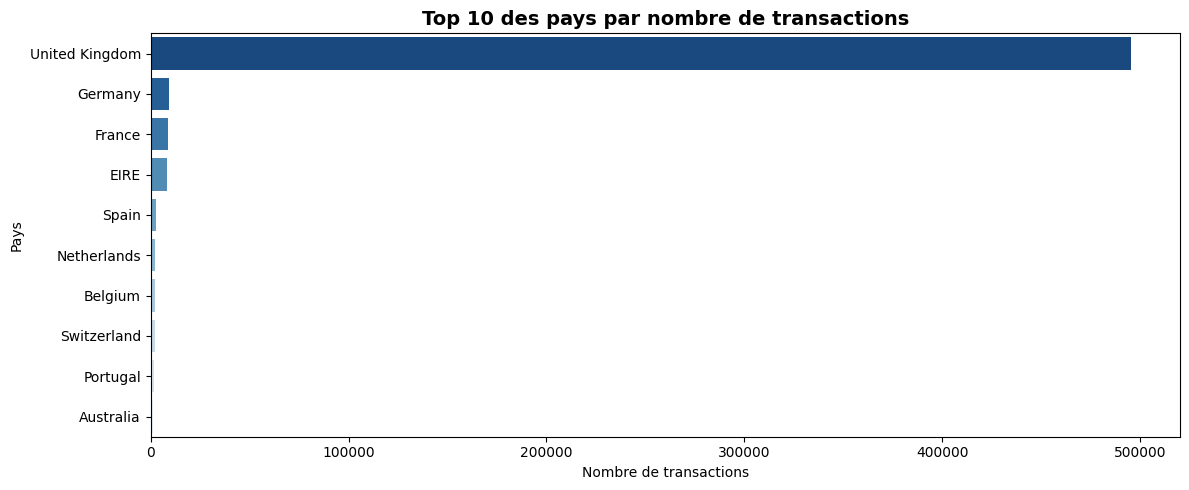

UK représente 91.4% des transactions


In [ ]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 des pays par nombre de transactions', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de transactions')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()
print(f"UK représente {top_countries['United Kingdom']/len(df)*100:.1f}% des transactions")

Évolution du chiffre d’affaires dans le temps

<Axes: xlabel='Month'>

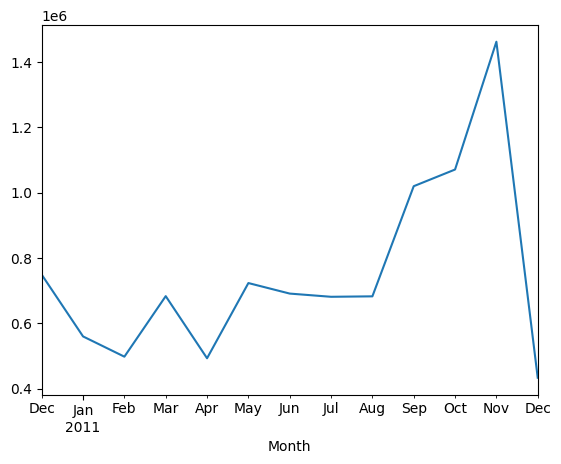

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('Month')['Revenue'].sum().plot()

Analyse des annulations

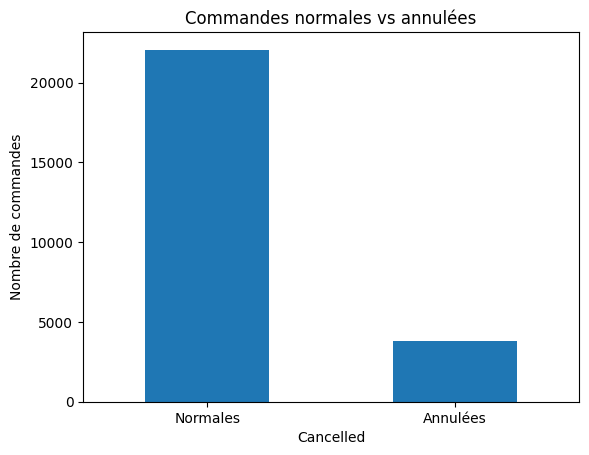

In [ ]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')

orders_status = df.groupby('Cancelled')['InvoiceNo'].nunique()

orders_status.plot(kind='bar')
plt.title("Commandes normales vs annulées")
plt.xticks([0,1], ['Normales', 'Annulées'], rotation=0)
plt.ylabel("Nombre de commandes")
plt.show()

Analyse Prix

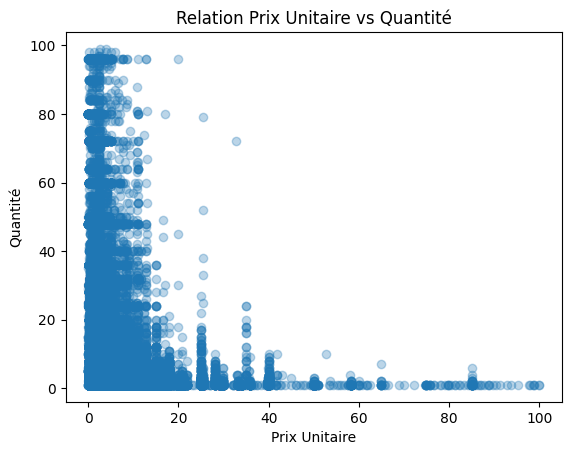

In [ ]:
df_positive = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df_filtered = df_positive[(df_positive['UnitPrice'] < 100) & (df_positive['Quantity'] < 100)]

plt.scatter(df_filtered['UnitPrice'], df_filtered['Quantity'], alpha=0.3)
plt.title("Relation Prix Unitaire vs Quantité")
plt.xlabel("Prix Unitaire")
plt.ylabel("Quantité")
plt.show()

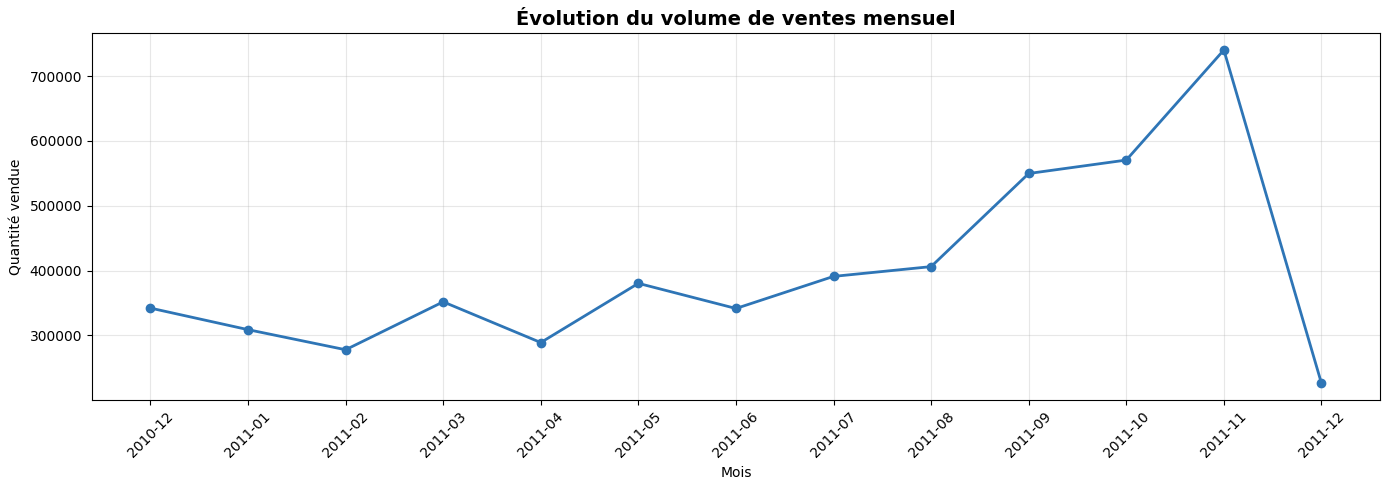

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Quantity'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Quantity'], marker='o', color='#2E75B6', linewidth=2)
plt.title('Évolution du volume de ventes mensuel', fontsize=14, fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Quantité vendue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Distribution des prix

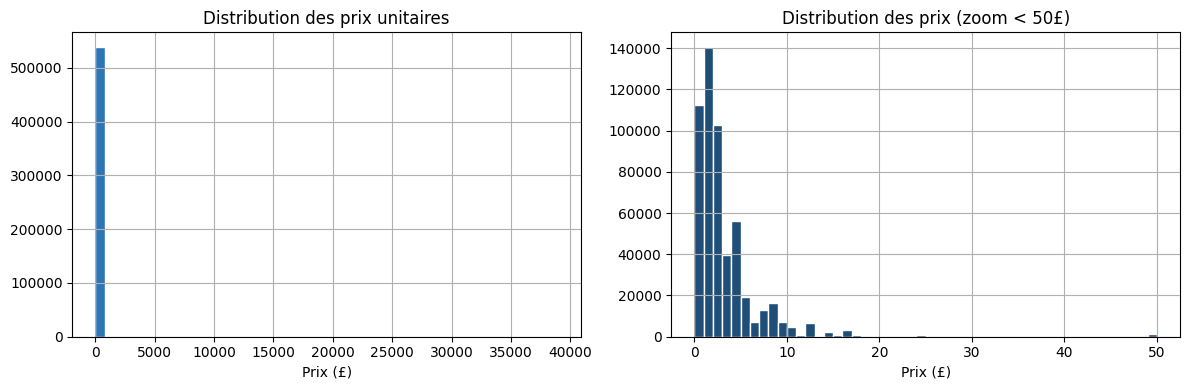

In [ ]:
df_clean = df[df['UnitPrice'] > 0]  # Exclure les prix à 0

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df_clean['UnitPrice'].hist(bins=50, color='#2E75B6', edgecolor='white')
plt.title('Distribution des prix unitaires')
plt.xlabel('Prix (£)')

plt.subplot(1, 2, 2)
df_clean['UnitPrice'].clip(upper=50).hist(bins=50, color='#1F4E79', edgecolor='white')
plt.title('Distribution des prix (zoom < 50£)')
plt.xlabel('Prix (£)')

plt.tight_layout()
plt.show()